In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# CSVファイルを読み込む（nrowsで読み込む行数を指定できるのでメモリに優しい）
df = pd.read_csv('run2026_2_none.csv')
print(len(df))

29812580


In [13]:
df[950:1000]

,iEve,HitIdx,GRX,GRA,GRY,GRB,GRQ2timing,GRQ2charge,LASX,LASA,LASY,LASB,LASQ1timing,LASTOT
950,207,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162758.0,NaN
951,207,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.15570
952,207,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154.12700
953,207,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.58000
954,207,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.96420
955,207,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,126.86200
956,207,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,145.87300
957,207,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113.04600
958,207,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128.16200
959,208,0,NaN,NaN,NaN,NaN,427165.0,63.7709,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# # 1. データの読み込み（-9999 を NaN に変換しておく）
# df = pd.read_csv("run2026_2_none.csv").replace(-9999, np.nan)

# 2. GRXが有効な（NaNではない）行だけを抽出
df_valid_grx = df[df['LASTOT'].notna()]

# 3. イベント(iEve)ごとに、行数（＝ヒット数）をカウントする
hit_counts = df_valid_grx.groupby('iEve').size()

# 4. ヒット数が2以上のイベントだけを抽出
multi_hit_events = hit_counts[hit_counts >= 2]

# --- 結果の表示 ---
if multi_hit_events.empty:
    print("GRXに2つ以上の意味のある値を持つイベントは存在しませんでした。")
else:
    print(f"GRXが2ヒット以上したイベントは {len(multi_hit_events)} 件あります。")
    print("\n【該当するイベント番号とヒット数】")
    print(len(multi_hit_events)) # 最初の10件だけ表示

GRXが2ヒット以上したイベントは 4213364 件あります。

【該当するイベント番号とヒット数】
4213364


In [2]:
import pandas as pd
import numpy as np

# 1. データの読み込み (-9999 を NaN に変換)
df = pd.read_csv("run2026_2_none.csv").replace(-9999, np.nan)

# 2. VDCの代表値を抽出（イベントごとに「最初の有効な値」を1行にまとめる）
vdc_cols = ['GRX', 'GRA', 'GRY', 'GRB', 'LASX', 'LASA', 'LASY', 'LASB']
df_vdc = df.groupby('iEve')[vdc_cols].first().reset_index()

# 3. LASTOTの全ヒットを抽出（NaNではない行を全て残す）
# ※もし前回のやり取りで WireID 列を追加していた場合はリストに 'WireID' も含めてください
df_tot = df[df['LASTOT'].notna()][['iEve', 'HitIdx', 'LASTOT']]

# 4. 結合（TOTの複数行データに対して、VDCの代表値1行をくっつける）
# how='inner' にすることで、VDCとLASTOTの両方があるイベントのみ残します
df_result = pd.merge(df_tot, df_vdc, on='iEve', how='inner')

# 見やすくするために列の順番を整理（任意）
df_result = df_result[['iEve', 'HitIdx', 'GRX', 'GRA', 'LASX', 'LASA', 'LASTOT']]

print(df_result)

             iEve  HitIdx  GRX  GRA    LASX      LASA   LASTOT
0               0       0  NaN  NaN     NaN       NaN  21.9437
1               0       1  NaN  NaN     NaN       NaN  79.8983
2               0       2  NaN  NaN     NaN       NaN  47.4986
3               2       0  NaN  NaN     NaN       NaN  51.4844
4               2       1  NaN  NaN     NaN       NaN  69.9005
...           ...     ...  ...  ...     ...       ...      ...
18255580  5946776      29  NaN  NaN -153.73  0.068915  21.7983
18255581  5946776      30  NaN  NaN -153.73  0.068915  42.2535
18255582  5946776      31  NaN  NaN -153.73  0.068915  51.3268
18255583  5946776      32  NaN  NaN -153.73  0.068915  44.6305
18255584  5946776      33  NaN  NaN -153.73  0.068915  67.6570

[18255585 rows x 7 columns]


In [18]:
# import pandas as pd
# import numpy as np

# # 1. データの読み込み (-9999 を NaN に変換)
# df = pd.read_csv("run2026_2_none.csv").replace(-9999, np.nan)

# ==========================================
# 処理A: LASTOTの平均値を計算する
# ==========================================
# LASTOTが有効な行だけを抽出
df_tot = df[df['LASTOT'].notna()]

# イベント(iEve)ごとにグループ化し、LASTOTの「平均値(mean)」を計算する
# as_index=False をつけることで、iEveがインデックスではなく通常の列として残ります
df_tot_mean = df_tot.groupby('iEve', as_index=False)['LASTOT'].mean()

# ==========================================
# 処理B: VDC(飛跡)データと結合する
# ==========================================
# VDCは代表値（最初の有効な値）を採用
vdc_cols = ['GRX', 'GRA', 'GRY', 'GRB', 'GRQ2timing', 'GRQ2charge', 'LASX', 'LASA', 'LASY', 'LASB', 'LASQ1timing']
df_vdc = df.groupby('iEve')[vdc_cols].first().reset_index()

# 飛跡データと、先ほど計算したLASTOTの平均値を結合（インナージョイン）
df_result = pd.merge(df_vdc, df_tot_mean, on='iEve', how='inner')

df_result = df_result.dropna(subset=['GRX', 'LASX'])

# 見やすくするために列の順番を整理
df_result = df_result[['iEve', 'GRX', 'GRA', 'GRY', 'GRB', 'GRQ2timing', 'GRQ2charge', 'LASX', 'LASA', 'LASY', 'LASB', 'LASQ1timing', 'LASTOT']]

print("【イベントごとに平均化されたデータ】")
df_result[:50]



【イベントごとに平均化されたデータ】


,iEve,GRX,GRA,GRY,GRB,GRQ2timing,GRQ2charge,LASX,LASA,LASY,LASB,LASQ1timing,LASTOT
53,136,474.31300,-0.008978,-9.694570,0.001559,88093.10,708.087,192.0400,-0.059215,-64.643600,-0.020240,88051.100,53.117453
65,165,-46.55320,-0.039124,13.807300,-0.070023,465731.00,200.527,283.3850,0.008039,-16.133600,0.286321,466112.000,137.439558
79,213,-431.21600,0.001858,15.986600,0.000871,303154.00,230.676,-199.8040,-0.134347,-59.791900,-0.015766,303242.000,173.751496
125,330,554.33100,-0.090823,14.302600,0.017963,27952.90,276.807,254.1210,-0.065348,-41.244600,-0.011579,28108.100,108.221913
143,370,307.52300,0.025597,-1.650630,0.002547,385360.00,447.768,474.9690,0.154485,-29.407300,-0.000157,385321.000,90.203542
176,469,-405.05200,-0.036694,-26.977400,0.233730,19022.70,529.979,147.1340,-0.149019,-7.549030,0.012222,18959.000,116.234804
185,485,160.22000,0.037943,4.967640,-0.002955,229722.00,182.104,-371.8490,0.122114,23.559100,0.021145,229863.000,55.846278
229,587,-577.06800,0.136369,14.199200,-0.008875,31495.60,611.980,-254.9070,-0.165511,172.663000,-0.483385,31896.000,67.750052
274,687,-78.95520,-0.032735,-21.353300,0.005911,311322.00,498.847,-131.3540,-0.133028,-34.747500,-0.165219,311708.000,70.787979
281,701,91.96020,0.001881,0.889834,-0.001222,350620.00,269.280,86.8237,0.200393,-2097.340000,3.114980,350704.000,146.171966


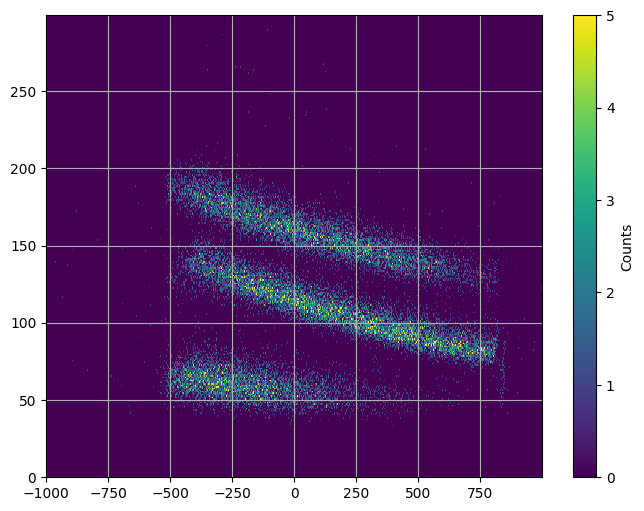

In [14]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=df_result['LASX']
y_axis_variable=df_result['LASTOT']
#hist range
x_axis_range_min = -1000
x_axis_range_max = 1000
y_axis_range_min = 0
y_axis_range_max = 300
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 2)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
# ax.set_xlabel('T_alpha[MeV]')
# ax.set_ylabel('Tp[MeV]')
ax.grid()

In [20]:
df = df_result
GRtiming = df['GRQ2timing']
LASX = df['LASX']
LAStiming = df['LASQ1timing']
TOT = df['LASTOT']

xdp=df['GRX']
adp=df['GRA']
ydp=df['GRY']
bdp=df['GRB']
GRQ2=df['GRQ2charge']

tracking_gated=df[
    (df['GRX']!=-9999) & (df['GRY']!=-9999)
]

xdp_track=tracking_gated['GRX']
adp_track=tracking_gated['GRA']
ydp_track=tracking_gated['GRY']
bdp_track=tracking_gated['GRB']
GRQ2_track=tracking_gated['GRQ2charge']

# proton_gated=tracking_gated[
#     (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5)
# ]

# xdp_proton=proton_gated['GRX']
# adp_proton=proton_gated['GRA']
# ydp_proton=proton_gated['GRY']
# bdp_proton=proton_gated['GRB']
# GRQ2_proton=proton_gated['GRQ2charge']

#合わせる時は、GRQ2_trackとTOTを抽出してから
# gated = df[
#     (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>140) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<170)
# ]
# GRQ2timing_gated = gated['GRQ2timing']
# LASQ1timing_gated = gated['LASQ1timing']

In [21]:
gated = df[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>140) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<170)
]

In [22]:
gated

,iEve,GRX,GRA,GRY,GRB,GRQ2timing,GRQ2charge,LASX,LASA,LASY,LASB,LASQ1timing,LASTOT
65,165,-46.5532,-0.039124,13.807300,-0.070023,465731.0,200.527,283.3850,0.008039,-16.1336,0.286321,466112.0,137.439558
79,213,-431.2160,0.001858,15.986600,0.000871,303154.0,230.676,-199.8040,-0.134347,-59.7919,-0.015766,303242.0,173.751496
281,701,91.9602,0.001881,0.889834,-0.001222,350620.0,269.280,86.8237,0.200393,-2097.3400,3.114980,350704.0,146.171966
548,1293,266.6860,-0.014362,3.570800,-0.001287,105452.0,198.322,-320.6710,0.110852,-25.9856,0.002234,105365.0,167.722995
582,1371,-119.9730,-0.034760,-15.442900,0.003660,224680.0,263.702,49.4976,0.038816,-35.4920,-0.007573,224767.0,163.962553
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2545703,5946214,-129.0030,-0.028019,-17.972800,0.003862,429737.0,189.351,-311.7950,0.129594,14.0309,0.006555,430059.0,176.409692
2545754,5946319,186.1630,0.010301,19.237500,-0.004590,219711.0,218.169,-351.1340,-0.177895,-28.1351,-0.000423,220164.0,181.004657
2545773,5946355,-78.8341,0.011152,-30.965400,0.006082,316178.0,232.526,64.8252,0.045539,88.6055,0.057665,316260.0,154.523926
2545876,5946580,-222.1470,-0.033318,-23.460500,0.003556,51493.1,234.663,213.6160,-0.066629,-15.4555,-0.013431,51403.9,151.376919


Text(0, 0.5, 'counts')

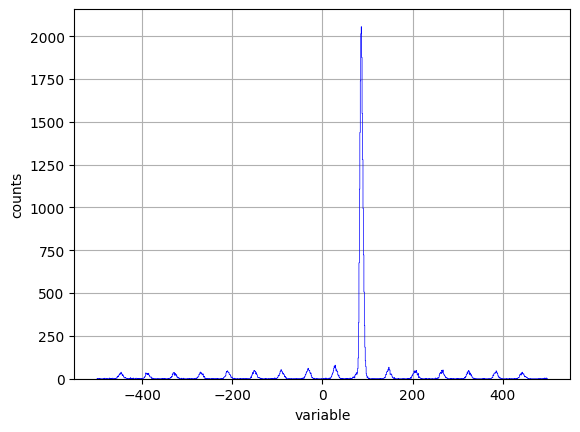

In [24]:
GRQ2timing_gated = gated['GRQ2timing']
LASQ1timing_gated = gated['LASQ1timing']

#TDiffのスペクトル
TDiff = LASQ1timing_gated - GRQ2timing_gated

#input
####################################################
#variables
variable=TDiff
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width = 1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')